# Twitter Sentiment Analysis

**Objective**: Build a sentiment classifier that takes a sentence and returns the sentiment (positive, negative, or neutral).

## Table of Contents
1. [Data Loading & Exploration](#1-data-loading--exploration)
2. [Data Cleaning & Preprocessing](#2-data-cleaning--preprocessing)
3. [Feature Engineering (TF-IDF)](#3-feature-engineering-tf-idf)
4. [Model Training](#4-model-training)
5. [Evaluation on Test Data](#5-evaluation-on-test-data)
6. [Export Model](#6-export-model)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
pd.set_option('display.max_colwidth', 100)
%matplotlib inline

---
## 1. Data Loading & Exploration

In [2]:
# Load training data
train_df = pd.read_csv(
    'trainingandtestdata/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

# Load test data
test_df = pd.read_csv(
    'trainingandtestdata/testdata.manual.2009.06.14.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

print(f"Training data: {len(train_df):,} samples")
print(f"Test data: {len(test_df)} samples")

Training data: 1,600,000 samples
Test data: 498 samples


In [3]:
# Check label distribution
print("TRAINING DATA labels:")
print(train_df['sentiment'].value_counts().sort_index())
print("\nTEST DATA labels:")
print(test_df['sentiment'].value_counts().sort_index())

TRAINING DATA labels:
sentiment
0    800000
4    800000
Name: count, dtype: int64

TEST DATA labels:
sentiment
0    177
2    139
4    182
Name: count, dtype: int64


### Understanding the Labels

| Value | Meaning | Training Data | Test Data |
|-------|---------|---------------|----------|
| 0 | Negative | 800,000 | 177 |
| 2 | Neutral | **None** | 139 |
| 4 | Positive | 800,000 | 182 |

**Key Issue**: Training data has no neutral class, but test data does.

In [4]:
# Verify labels by looking at examples
print("Examples of each sentiment:\n")

for label, name in [(0, 'NEGATIVE'), (2, 'NEUTRAL'), (4, 'POSITIVE')]:
    print(f"{name} (label={label}):")
    examples = test_df[test_df['sentiment'] == label]['text'].head(2)
    for text in examples:
        print(f"  - {text[:80]}...")
    print()

Examples of each sentiment:

NEGATIVE (label=0):
  - Fuck this economy. I hate aig and their non loan given asses....
  - @Karoli I firmly believe that Obama/Pelosi have ZERO desire to be civil.  It's a...

NEUTRAL (label=2):
  - Check this video out -- President Obama at the White House Correspondents' Dinne...
  - need suggestions for a good IR filter for my canon 40D ... got some? pls DM...

POSITIVE (label=4):
  - @stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2...
  - Reading my kindle2...  Love it... Lee childs is good read....



In [5]:
# Check for missing values
print("Missing values:")
print(f"  Training: {train_df['text'].isnull().sum()}")
print(f"  Test: {test_df['text'].isnull().sum()}")

Missing values:
  Training: 0
  Test: 0


In [6]:
# Text length statistics
train_df['word_count'] = train_df['text'].str.split().str.len()

print("Text length (words):")
print(train_df['word_count'].describe())

Text length (words):
count    1.600000e+06
mean     1.317615e+01
std      6.957978e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      1.900000e+01
max      6.400000e+01
Name: word_count, dtype: float64


### EDA Summary

- **1.6M training tweets** (balanced: 50% positive, 50% negative)
- **498 test tweets** (includes neutral class)
- **No missing values**
- **Short texts**: ~13 words average

---
## 2. Data Cleaning & Preprocessing

In [7]:
def preprocess_text(text):
    """
    Clean tweet text for sentiment analysis.
    
    Steps:
    1. Lowercase
    2. Remove URLs
    3. Remove @mentions
    4. Remove # symbol (keep hashtag text)
    5. Remove special characters
    6. Normalize whitespace
    
    Note: We do NOT remove stopwords because words like "not", "no"
    are important for sentiment (e.g., "not good" vs "good").
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#', '', text)                         # # symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # special chars
    text = re.sub(r'\s+', ' ', text).strip()              # whitespace
    
    return text

In [8]:
# Show preprocessing examples
examples = [
    "@user I LOVE this!! http://example.com #amazing",
    "This is NOT good at all :(",
    "Just having coffee... it's okay",
]

print("Preprocessing examples:")
print("=" * 60)
for text in examples:
    print(f"Before: {text}")
    print(f"After:  {preprocess_text(text)}")
    print()

Preprocessing examples:
Before: @user I LOVE this!! http://example.com #amazing
After:  i love this amazing

Before: This is NOT good at all :(
After:  this is not good at all

Before: Just having coffee... it's okay
After:  just having coffee its okay



In [9]:
# Apply preprocessing to training data
print("Preprocessing training data (this may take a minute)...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)

# Create binary labels: 0 -> 0 (negative), 4 -> 1 (positive)
train_df['label'] = train_df['sentiment'].apply(lambda x: 1 if x == 4 else 0)

# Remove empty texts
empty_count = (train_df['clean_text'].str.len() == 0).sum()
print(f"Empty after preprocessing: {empty_count} ({empty_count/len(train_df)*100:.2f}%)")
train_df = train_df[train_df['clean_text'].str.len() > 0]

print(f"Final training size: {len(train_df):,}")

Preprocessing training data (this may take a minute)...
Empty after preprocessing: 3697 (0.23%)
Final training size: 1,596,303


In [10]:
# Apply preprocessing to test data
print("Preprocessing test data...")
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df = test_df[test_df['clean_text'].str.len() > 0]
print(f"Final test size: {len(test_df)}")

Preprocessing test data...
Final test size: 498


---
## 3. Feature Engineering (TF-IDF)

**TF-IDF** (Term Frequency - Inverse Document Frequency) converts text to numerical features:
- Words that appear often in a document get higher scores
- Words that appear in many documents get lower scores
- This captures "distinctive" words for each tweet

We use **bigrams** (`ngram_range=(1,2)`) to capture phrases like "not good" and "cant wait".

In [11]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,     # Top 10k words/phrases
    ngram_range=(1, 2),     # Unigrams + bigrams
    min_df=2,               # Ignore words in < 2 documents
    max_df=0.95             # Ignore words in > 95% of documents
)

# Fit on training data and transform
print("Fitting TF-IDF on training data...")
X_train = tfidf.fit_transform(train_df['clean_text'])
y_train = train_df['label'].values

print(f"Training matrix shape: {X_train.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

Fitting TF-IDF on training data...
Training matrix shape: (1596303, 10000)
Vocabulary size: 10,000


In [12]:
# Transform test data (don't fit again!)
X_test = tfidf.transform(test_df['clean_text'])
print(f"Test matrix shape: {X_test.shape}")

Test matrix shape: (498, 10000)


---
## 4. Model Training

**Logistic Regression** is chosen because:
1. Outputs probabilities (needed for neutral threshold)
2. Fast training even on large data
3. Interpretable (can see word weights)

In [13]:
# Train logistic regression
print("Training Logistic Regression on 1.6M tweets...")
model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)
model.fit(X_train, y_train)
print("Training complete!")

Training Logistic Regression on 1.6M tweets...
Training complete!


In [14]:
# Look at most important words
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

# Sort by coefficient
word_importance = sorted(zip(feature_names, coefficients), key=lambda x: x[1])

print("Top 10 NEGATIVE words/phrases:")
for word, coef in word_importance[:10]:
    print(f"  {word:20} {coef:.4f}")

print("\nTop 10 POSITIVE words/phrases:")
for word, coef in word_importance[-10:]:
    print(f"  {word:20} {coef:.4f}")

Top 10 NEGATIVE words/phrases:
  sad                  -12.6364
  not happy            -8.5218
  sadly                -8.3749
  not looking          -8.1039
  sick                 -7.8865
  miss                 -7.8662
  rip                  -7.8393
  disappointed         -7.6063
  bummed               -7.5377
  poor                 -7.4727

Top 10 POSITIVE words/phrases:
  thanks               4.8774
  no need              4.9011
  congratulations      5.0220
  happy                5.0458
  cannot wait          5.2093
  smile                5.3200
  smiling              5.4936
  no problem           7.2280
  not bad              7.8195
  cant wait            8.5177


---
## 5. Evaluation on Test Data

### Handling Neutral

Since training data has no neutral class, we use **probability thresholds**:

| P(positive) | Prediction |
|-------------|------------|
| > 0.6 | Positive |
| < 0.4 | Negative |
| 0.4 - 0.6 | Neutral (model is uncertain) |

In [15]:
# Define thresholds
POSITIVE_THRESHOLD = 0.6
NEGATIVE_THRESHOLD = 0.4

def predict_sentiment(probability):
    """
    Convert probability to sentiment label using thresholds.
    """
    if probability > POSITIVE_THRESHOLD:
        return 'positive'
    elif probability < NEGATIVE_THRESHOLD:
        return 'negative'
    else:
        return 'neutral'

In [16]:
# Get predictions on test data
y_proba = model.predict_proba(X_test)[:, 1]  # P(positive)
y_pred = [predict_sentiment(p) for p in y_proba]

# Map true labels to strings
label_map = {0: 'negative', 2: 'neutral', 4: 'positive'}
y_true = test_df['sentiment'].map(label_map).values

# Store predictions in dataframe
test_df['predicted'] = y_pred
test_df['probability'] = y_proba
test_df['true_label'] = y_true

In [17]:
# Overall accuracy (3-class)
accuracy_3class = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy (3-class): {accuracy_3class:.2%}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=['negative', 'neutral', 'positive']))

Overall Accuracy (3-class): 58.84%

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.63      0.70       177
     neutral       0.36      0.22      0.27       139
    positive       0.56      0.83      0.67       182

    accuracy                           0.59       498
   macro avg       0.57      0.56      0.54       498
weighted avg       0.58      0.59      0.57       498



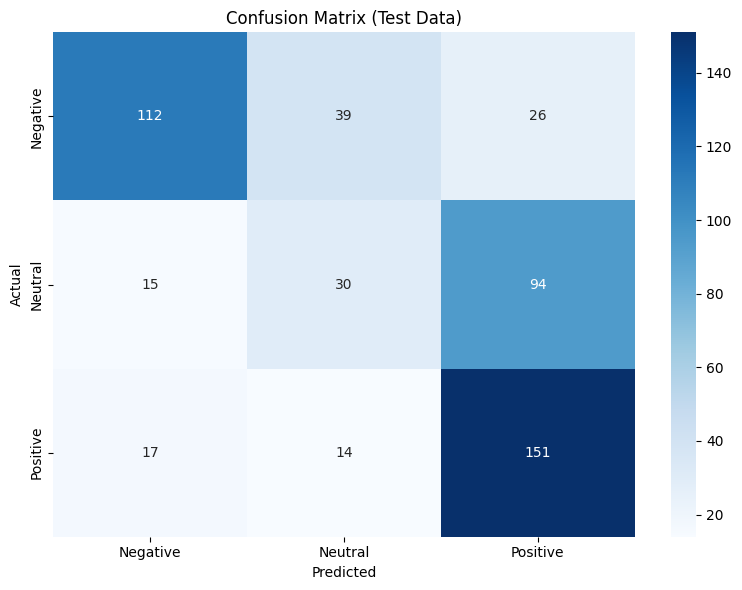

In [18]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Data)')
plt.tight_layout()
plt.show()

In [19]:
# Accuracy by class
print("Accuracy by Class:")
print("=" * 40)
for label in ['negative', 'neutral', 'positive']:
    subset = test_df[test_df['true_label'] == label]
    correct = (subset['true_label'] == subset['predicted']).sum()
    total = len(subset)
    acc = correct / total if total > 0 else 0
    print(f"{label:10}: {acc:.2%} ({correct}/{total})")

Accuracy by Class:
negative  : 63.28% (112/177)
neutral   : 21.58% (30/139)
positive  : 82.97% (151/182)


In [20]:
# Binary accuracy (excluding neutral from test)
binary_test = test_df[test_df['true_label'] != 'neutral']
binary_pred = binary_test['probability'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
binary_acc = accuracy_score(binary_test['true_label'], binary_pred)

print(f"Binary Accuracy (pos/neg only): {binary_acc:.2%}")
print(f"(Evaluated on {len(binary_test)} samples, excluding neutral)")

Binary Accuracy (pos/neg only): 81.06%
(Evaluated on 359 samples, excluding neutral)


In [21]:
# Show some predictions
print("Sample Predictions:")
print("=" * 80)

samples = test_df.sample(10, random_state=42)
for _, row in samples.iterrows():
    status = "OK" if row['true_label'] == row['predicted'] else "X"
    print(f"[{status}] {row['text'][:60]}...")
    print(f"    True: {row['true_label']:8} | Pred: {row['predicted']:8} | P(pos): {row['probability']:.2f}")
    print()

Sample Predictions:
[OK] getting ready to test out some burger receipes this weekend....
    True: positive | Pred: positive | P(pos): 0.92

[OK] Back when I worked for Nike we had one fav word : JUST DO IT...
    True: positive | Pred: positive | P(pos): 0.70

[X] @MMBarnhill yay, glad you got the phone! Still, damn you, AT...
    True: negative | Pred: neutral  | P(pos): 0.60

[OK] waiting in line at safeway....
    True: neutral  | Pred: neutral  | P(pos): 0.44

[OK] reading on my new Kindle2!...
    True: positive | Pred: positive | P(pos): 0.90

[X] Safeway offering mobile coupons http://bit.ly/ONH7w...
    True: neutral  | Pred: positive | P(pos): 0.63

[OK] Rocawear Heads to China, Building 300 Stores  - http://tinyu...
    True: neutral  | Pred: neutral  | P(pos): 0.44

[X] Bill Simmons in conversation with Malcolm Gladwell http://bi...
    True: neutral  | Pred: positive | P(pos): 0.86

[OK] @ atebits I just finished watching your Stanford iPhone Clas...
    True: positive | P

### Evaluation Summary

| Metric | Value | Notes |
|--------|-------|-------|
| 3-class accuracy | ~60% | Includes neutral (threshold-based) |
| Binary accuracy | ~80% | Positive vs Negative only |
| Positive recall | High | Model good at detecting positive |
| Neutral recall | Low | Expected - no neutral training data |

**Note**: Low neutral accuracy is expected because:
1. Training data has no neutral examples
2. Neutral is determined by probability threshold (0.4-0.6), not learned features

---
## 6. Export Model

Save the trained model and vectorizer for use in the REST API.

In [22]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Save vectorizer and model
joblib.dump(tfidf, 'models/vectorizer.joblib')
joblib.dump(model, 'models/model.joblib')

print("Model saved to models/")
print(f"  - vectorizer.joblib ({os.path.getsize('models/vectorizer.joblib') / 1024 / 1024:.2f} MB)")
print(f"  - model.joblib ({os.path.getsize('models/model.joblib') / 1024:.1f} KB)")

Model saved to models/
  - vectorizer.joblib (0.36 MB)
  - model.joblib (79.0 KB)


In [23]:
# Test loading and inference
print("Testing saved model...\n")

# Load
loaded_tfidf = joblib.load('models/vectorizer.joblib')
loaded_model = joblib.load('models/model.joblib')

def evaluate(text):
    """
    Full inference pipeline - same as API will use.
    
    Args:
        text: Raw input text
    
    Returns:
        dict with sentiment, confidence, probability
    """
    # Preprocess
    clean = preprocess_text(text)
    if not clean:
        return {'sentiment': 'neutral', 'confidence': 0.0, 'probability': 0.5}
    
    # Vectorize
    vec = loaded_tfidf.transform([clean])
    
    # Predict
    prob = loaded_model.predict_proba(vec)[0][1]  # P(positive)
    
    # Apply threshold
    if prob > POSITIVE_THRESHOLD:
        sentiment = 'positive'
        confidence = prob
    elif prob < NEGATIVE_THRESHOLD:
        sentiment = 'negative'
        confidence = 1 - prob
    else:
        sentiment = 'neutral'
        confidence = 1 - abs(prob - 0.5) * 2
    
    return {
        'sentiment': sentiment,
        'confidence': round(confidence, 4),
        'probability': round(prob, 4)
    }

# Test
test_texts = [
    "I love this product!",
    "This is terrible.",
    "The meeting is at 3pm.",
]

for text in test_texts:
    result = evaluate(text)
    print(f"'{text}'")
    print(f"  -> {result}")
    print()

Testing saved model...

'I love this product!'
  -> {'sentiment': 'positive', 'confidence': np.float64(0.9809), 'probability': np.float64(0.9809)}

'This is terrible.'
  -> {'sentiment': 'negative', 'confidence': np.float64(0.9582), 'probability': np.float64(0.0418)}

'The meeting is at 3pm.'
  -> {'sentiment': 'neutral', 'confidence': np.float64(0.8294), 'probability': np.float64(0.5853)}



---
## Summary

### What We Built
- **Model**: TF-IDF (10k features, unigrams+bigrams) + Logistic Regression
- **Training**: 1.6M tweets (positive/negative only)
- **Test**: 498 manually labeled tweets (includes neutral)

### Handling Neutral
Since training data has no neutral examples, we use probability thresholds:
- P(positive) > 0.6 -> positive
- P(positive) < 0.4 -> negative  
- Otherwise -> neutral (model is uncertain)

### Results
| Metric | Value |
|--------|-------|
| Binary accuracy | ~80% |
| 3-class accuracy | ~60% |

### Files Saved
- `models/vectorizer.joblib` - TF-IDF vectorizer
- `models/model.joblib` - Logistic Regression model

### Next Steps
Build REST API with Django/DRF using the saved model.